# Read and plot one ATST readout

All conditions in `moi10_all`; labels, colours and units follow the ATST data.


In [1]:
from IPython.display import display
from ATST import read_atst

study = read_atst("atst_costa_2024/atst_costa_2024.atst.txt", multi_readouts=True)
readout_id = study.readout_ids[0]
readout = study.readouts[readout_id]


In [2]:
readout.layout.data.columns

Index(['curve_id', 'type', 'isolate_id', 'phage_id', 'pfu_ml', 'replicate'], dtype='str')

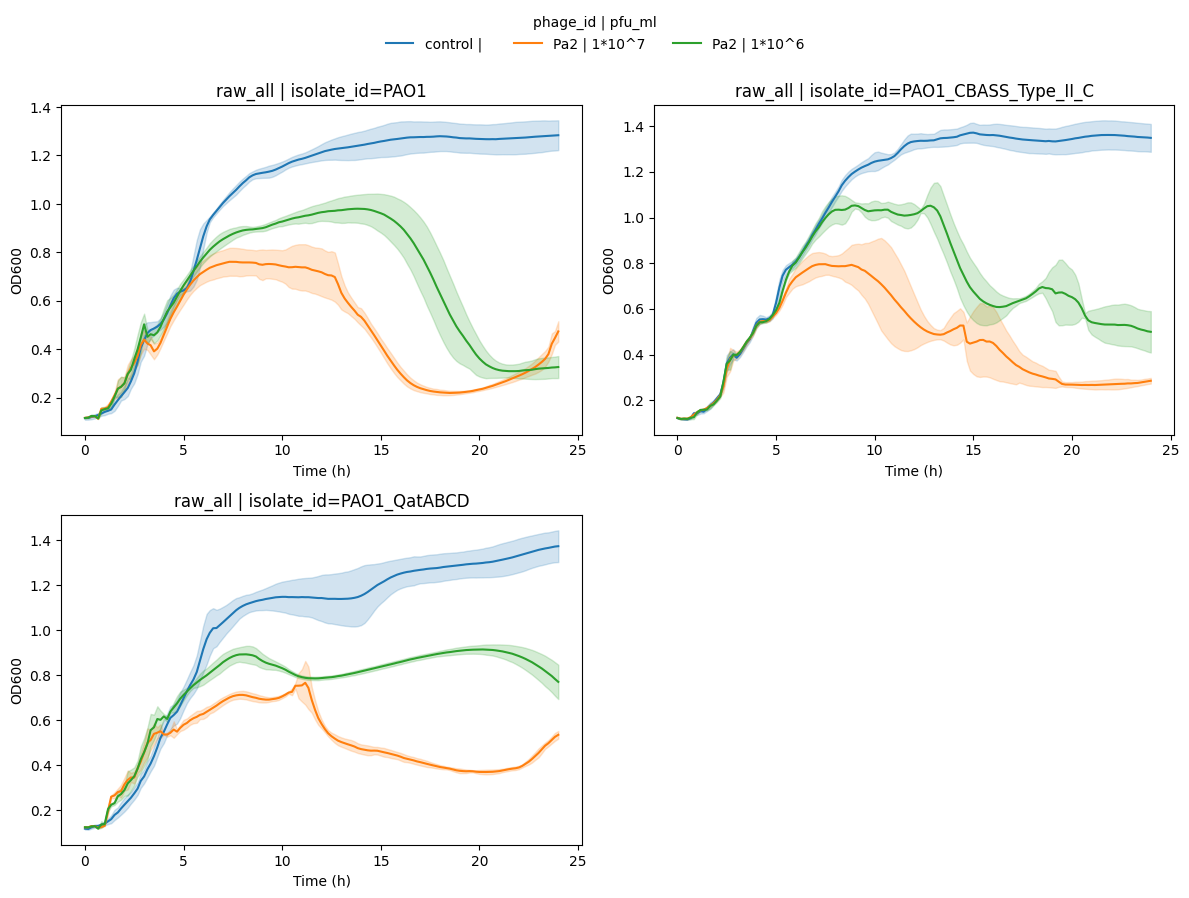

In [3]:
readout.plot(
    group_by=["phage_id",
              "pfu_ml"],
    facet_by=["isolate_id"],
    summary="mean_sd",
    filters={"phage_id": ["Pa2", ""]},
    require_all_filters=True
)


Individual source curves are shown; the merged readout repeats control replicate IDs within some isolate/condition groups.


In [4]:
for name, block in [
    ("FILE_INFO", study.file_info),
    ("STUDY", study.study),
    ("METADATA", readout.metadata),
    ("ASSAY", readout.assay),
]:
    print(name)
    display(block.data)
print("LAYOUT")
display(readout.layout.data)
for name, table in study.entities.tables.items():
    print(name)
    display(table.data)


FILE_INFO


{'file_name': 'atst_costa_2024.atst.txt',
 'format': 'ATST',
 'format_version': '0.1',
 'created_on': '2026-10-08',
 'field_delimiter': 'TAB',
 'encoding': 'UTF-8'}

STUDY


{'title': 'Accumulation of defense systems in phage-resistant strains of Pseudomonas aeruginosa',
 'study_id': 'doi:10.1126/sciadv.adj0341',
 'authors': 'Ana Rita Costa; Daan F. van den Berg; Jelger Q. Esser; Aswin Muralidharan; Halewijn van den Bossche; Boris Estrada Bonilla; Baltus A. van der Steen; Anna C. Haagsma; Ad C. Fluit; Franklin L. Nobrega; Pieter-Jan Haas; Stan J. J. Brouns',
 'publication_date': '2024-02-23',
 'publication_doi': '10.1126/sciadv.adj0341',
 'dataset_doi': '10.5281/zenodo.8405451',
 'dataset_version': 'v1.0',
 'bioproject': 'PRJNA817167',
 'description': 'Liquid culture collapse assays of PAO1 carrying individual defense systems and an empty-vector comparator; both shared plate-reader workbooks.',
 'original_repository': 'https://github.com/BrounsLab-TUDelft/Pseudomonas_Defence_Systems/tree/v1.0'}

METADATA


...

,ISOLATE_ID,source_sheet,species,defense_system,plasmid_name,plasmid_code,vector,insert_description,donor_strain,resistance_marker,identity_note
0,PAO1,PAO1,Pseudomonas aeruginosa,none added,pEmpty,pTU646,pUCP20,-,,AmpR,PAO1 worksheet interpreted as empty-vector com...
1,PAO1_AVAST_Type_V,AVAST Type V,Pseudomonas aeruginosa,AVAST Type V,pAVAST_V,pTU652,pUCP20,AVAST Type V from P. aeruginosa L0213,L0213,AmpR,Worksheet names defense system; host and const...
2,PAO1_CBASS_Type_II_A,CBASS Type II-A,Pseudomonas aeruginosa,CBASS Type II-A,pCBASS_IIA,pTU651,pUCP20,CBASS Type II-A from P. aeruginosa L1361,L1361,AmpR,Worksheet names defense system; host and const...
3,PAO1_CBASS_Type_II_C,CBASS Type II-C,Pseudomonas aeruginosa,CBASS Type II-C,pCBASS_IIC,pTU649,pUCP20,CBASS Type II-C from P. aeruginosa L1347,L1347,AmpR,Worksheet names defense system; host and const...
4,PAO1_CBASS_Type_III,CBASS Type III,Pseudomonas aeruginosa,CBASS Type III-C,pCBASS_III,pTU650,pUCP20,CBASS Type III from P. aeruginosa L1361,L1361,AmpR,Workbook/Table S8 label Type III corresponds t...
5,PAO1_Druantia_Type_III,Druantia Type III,Pseudomonas aeruginosa,Druantia Type III,pDruantia_III,pTU619,pUCP20,Druantia type III from P. aeruginosa L0872,L0872,AmpR,Worksheet names defense system; host and const...
6,PAO1_QatABCD,QatABCD,Pseudomonas aeruginosa,QatABCD,pQatABCD,pTU623,pUCP20,QatABCD from P. aeruginosa K6156,K6156,AmpR,Worksheet names defense system; host and const...
7,PAO1_RADAR,RADAR,Pseudomonas aeruginosa,RADAR,pRADAR,pTU626,pUCP20,RADAR from P. aeruginosa L0872,L0872,AmpR,Worksheet names defense system; host and const...
8,PAO1_TerY_P,TerY-P,Pseudomonas aeruginosa,TerY-P,pTerY-P,pTU622,pUCP20,TerY-P from P. aeruginosa L1171,L1171,AmpR,Worksheet names defense system; host and const...
9,PAO1_Zorya_Type_I,Zorya Type I,Pseudomonas aeruginosa,Zorya Type I,pZorya_I,pTU620,pUCP20,Zorya Type I from P. aeruginosa K6024,K6024,AmpR,Worksheet names defense system; host and const...


PHAGES


,PHAGE_ID,published_name,table_s3_host_strain,genome_accession,accession_as_reported,genome_size_bp_as_reported,morphology_as_reported,family_as_reported,genus_as_reported,lifestyle_prediction_phageai,assay_stock_propagation_host
0,Pa2,vB_PaeM_FBPa2,L1264,ON857925,ON857925,65825,Myophage,NA,Pbunavirus,Virulent,PAO1
1,Pa3,vB_PaeP_FBPa3,N1520,ON857926,ON857926,43171,Podophage,Autographiviridae,-,Virulent,PAO1
2,Pa6,vB_PaeP_FBPa6,L1509,ON857928,ON857928,40865,Podophage,Autographiviridae,-,Virulent,PAO1
3,Pa10,vB_PaeM_FBPa10,K6156,ON857929,ON857929,66638,Myophage,NA,Pbunavirus,Virulent,PAO1
4,Pa12,vB_PaeM_FBPa12,K5993,ON857930,ON857930,66223,Myophage,NA,Pbunavirus,Virulent,PAO1
5,Pa18,vB_PaeS_FBPa18,L1165,ON857933,ON857933,45261,Podophage,Autographiviridae,-,Virulent,PAO1
6,Pa21,vB_PaeM_FBPa21,L1347,ON857942,ON857942,62511,Myophage,NA,Pbunavirus,Virulent,PAO1
7,Pa22,vB_PaeS_FBPa22,L1464,,TBD,42494,Podophage,Autographiviridae,-,Virulent,PAO1
8,Pa24,vB_PaeM_FBPa24,L1496,ON857934,ON857934,63382,Myophage,NA,Pbunavirus,Virulent,PAO1
9,Pa25,vB_PaeP_FBPa25,L1262,ON857935,ON857935,41566,Podophage,Autographiviridae,-,Virulent,PAO1


MEDIA


,MEDIUM_ID,name,formulation
0,LB,lysogeny broth,not reported
